Starting Training...
Epoch 1: Loss = 1.0338, Accuracy = 0.9107
Epoch 2: Loss = 0.8911, Accuracy = 0.9592
Epoch 3: Loss = 0.8642, Accuracy = 0.9692
Epoch 4: Loss = 0.8515, Accuracy = 0.9748
Epoch 5: Loss = 0.8438, Accuracy = 0.9779
Epoch 6: Loss = 0.8384, Accuracy = 0.9799
Epoch 7: Loss = 0.8345, Accuracy = 0.9818
Epoch 8: Loss = 0.8313, Accuracy = 0.9833
Epoch 9: Loss = 0.8287, Accuracy = 0.9842
Epoch 10: Loss = 0.8265, Accuracy = 0.9853
Epoch 11: Loss = 0.8245, Accuracy = 0.9862
Epoch 12: Loss = 0.8228, Accuracy = 0.9870
Epoch 13: Loss = 0.8213, Accuracy = 0.9877
Epoch 14: Loss = 0.8200, Accuracy = 0.9885
Epoch 15: Loss = 0.8188, Accuracy = 0.9891
Epoch 16: Loss = 0.8177, Accuracy = 0.9896
Epoch 17: Loss = 0.8168, Accuracy = 0.9900
Epoch 18: Loss = 0.8159, Accuracy = 0.9904
Epoch 19: Loss = 0.8151, Accuracy = 0.9906
Epoch 20: Loss = 0.8144, Accuracy = 0.9909
Test Accuracy: 0.9876


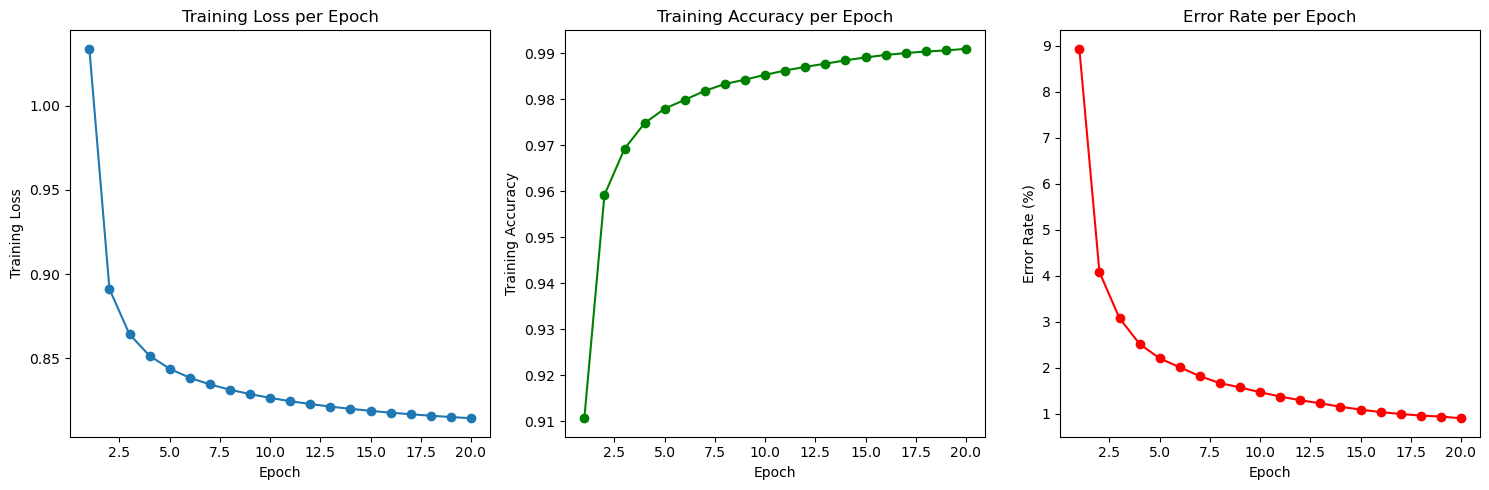

Training Metrics:
Accuracy: 0.9914333333333334
Precision: 0.9914362177914098
Recall: 0.9914333333333334
F1 Score: 0.9914318699618541
Confusion Matrix:
 [[5903    1    2    1    0    1    7    1    3    4]
 [   1 6711    8    0    3    0    2   13    4    0]
 [   4    4 5921    5    1    0    0   16    5    2]
 [   3    2   15 6059    0   11    1   18   10   12]
 [   3    5    4    0 5790    0    6    4    4   26]
 [   4    2    3   17    2 5361   16    1    5   10]
 [   7    4    1    0    3    7 5891    0    5    0]
 [   1   12   15    3    7    2    0 6206    5   14]
 [   7   14    7   10    8    9    4    5 5769   18]
 [   8    5    0    8   20    8    0   20    5 5875]]

Test Metrics:
Accuracy: 0.9876
Precision: 0.9876133462995693
Recall: 0.9876
F1 Score: 0.9875928403329397
Confusion Matrix:
 [[ 975    0    0    0    0    0    2    1    2    0]
 [   0 1132    1    0    0    1    1    0    0    0]
 [   2    4 1017    2    1    0    0    3    3    0]
 [   0    0    3 1002    0    0  

In [ ]:
import numpy as np
import numba
from tensorflow.keras.datasets import mnist

# Activation functions 
@numba.njit
def tanh_numba(x):
    return np.tanh(x)

@numba.njit
def dtanh_numba(x):
    t = np.tanh(x)
    return 1 - t*t

# Convolutions/Cross correlations
@numba.njit
def conv_forward_numba(x, weights, bias, stride):
    in_channels, H, W = x.shape
    out_channels, _, kh, kw = weights.shape
    H_out = (H - kh) // stride + 1
    W_out = (W - kw) // stride + 1
    out = np.empty((out_channels, H_out, W_out), dtype=x.dtype)
    for n in range(out_channels):
        for i in range(H_out):
            for j in range(W_out):
                s = 0.0
                for c in range(in_channels):
                    for p in range(kh):
                        for q in range(kw):
                            s += x[c, i*stride+p, j*stride+q] * weights[n, c, p, q]
                out[n, i, j] = s + bias[n]
    return out

@numba.njit
def conv_backward_numba(x, weights, dactivation, stride):
    in_channels, H, W = x.shape
    out_channels, _, kh, kw = weights.shape
    H_out = (H - kh) // stride + 1
    W_out = (W - kw) // stride + 1
    dW = np.zeros_like(weights)
    dB = np.zeros(out_channels, dtype=x.dtype)
    dx = np.zeros_like(x)
    for n in range(out_channels):
        for i in range(H_out):
            for j in range(W_out):
                da = dactivation[n, i, j]
                dB[n] += da
                for c in range(in_channels):
                    for p in range(kh):
                        for q in range(kw):
                            dW[n, c, p, q] += da * x[c, i*stride+p, j*stride+q]
                            dx[c, i*stride+p, j*stride+q] += da * weights[n, c, p, q]
    return dW, dB, dx

#Pooling
@numba.njit
def pool_forward_numba(x, pool_size, stride):
    channels, H, W = x.shape
    ph, pw = pool_size
    H_out = (H - ph) // stride + 1
    W_out = (W - pw) // stride + 1
    out = np.empty((channels, H_out, W_out), dtype=x.dtype)
    for c in range(channels):
        for i in range(H_out):
            for j in range(W_out):
                s = 0.0
                for p in range(ph):
                    for q in range(pw):
                        s += x[c, i*stride+p, j*stride+q]
                out[c, i, j] = s / (ph * pw)
    return out

@numba.njit
def pool_backward_numba(x, dactivation, pool_size, stride):
    channels, H, W = x.shape
    ph, pw = pool_size
    H_out = (H - ph) // stride + 1
    W_out = (W - pw) // stride + 1
    dx = np.zeros_like(x)
    for c in range(channels):
        for i in range(H_out):
            for j in range(W_out):
                grad = dactivation[c, i, j] / (ph * pw)
                for p in range(ph):
                    for q in range(pw):
                        dx[c, i*stride+p, j*stride+q] += grad
    return dx

# Layers 
class ConvLayer:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        kh, kw = kernel_size
        self.weights = np.random.randn(out_channels, in_channels, kh, kw) * np.sqrt(2.0 / (in_channels * kh * kw))
        self.bias = np.zeros(out_channels)
    
    def forward(self, x):
        self.input = x
        self.raw_output = conv_forward_numba(x, self.weights, self.bias, self.stride)
        self.out = tanh_numba(self.raw_output)
        return self.out

    def backward(self, dout, lr):
        dactivation = dout * dtanh_numba(self.raw_output)
        dW, dB, dx = conv_backward_numba(self.input, self.weights, dactivation, self.stride)
        self.weights -= lr * dW
        self.bias -= lr * dB
        return dx

class PoolLayer:
    def __init__(self, pool_size=(2,2), stride=2):
        if isinstance(pool_size, int):
            pool_size = (pool_size, pool_size)
        self.pool_size = pool_size
        self.stride = stride
        
    def forward(self, x):
        self.input = x
        self.raw_output = pool_forward_numba(x, self.pool_size, self.stride)
        self.out = tanh_numba(self.raw_output)
        return self.out
    
    def backward(self, dout, lr):
        dactivation = dout * dtanh_numba(self.raw_output)
        dx = pool_backward_numba(self.input, dactivation, self.pool_size, self.stride)
        return dx

class FCLayer:
    def __init__(self, input_dim, output_dim):
        self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
        self.bias = np.zeros(output_dim)
    def forward(self, x):
        self.input = x
        self.raw_output = np.dot(x, self.weights) + self.bias
        self.out = np.tanh(self.raw_output)
        return self.out
    def backward(self, dout, lr):
        dactivation = dout * (1 - np.tanh(self.raw_output)**2)
        dW = np.outer(self.input, dactivation)
        dB = dactivation
        dx = np.dot(dactivation, self.weights.T)
        self.weights -= lr * dW
        self.bias -= lr * dB
        return dx

class SoftmaxLayer:
    def forward(self, x):
        ex = np.exp(x - np.max(x))
        self.out = ex / np.sum(ex)
        return self.out
    def backward(self, dloss):
        return dloss

class LeNet5:
    def __init__(self):
        self.conv1 = ConvLayer(1, 6, 5, stride=1)       # Output: (6,28,28)
        self.pool1 = PoolLayer((2,2), stride=2)           # Output: (6,14,14)
        self.conv2 = ConvLayer(6, 16, 5, stride=1)        # Output: (16,10,10)
        self.pool2 = PoolLayer((2,2), stride=2)           # Output: (16,5,5)
        self.conv3 = ConvLayer(16, 120, 5, stride=1)       # Output: (120,1,1)
        self.fc1 = FCLayer(120, 84)                        # Fully connected: 120 -> 84
        self.fc2 = FCLayer(84, 10)                         # Fully connected: 84 -> 10
        self.softmax = SoftmaxLayer()
        
    def forward(self, x):
        x = x[np.newaxis, :, :] 
        self.out_conv1 = self.conv1.forward(x)
        self.out_pool1 = self.pool1.forward(self.out_conv1)
        self.out_conv2 = self.conv2.forward(self.out_pool1)
        self.out_pool2 = self.pool2.forward(self.out_conv2)
        self.out_conv3 = self.conv3.forward(self.out_pool2)
        self.flat = self.out_conv3.flatten()
        self.out_fc1 = self.fc1.forward(self.flat)
        self.out_fc2 = self.fc2.forward(self.out_fc1)
        self.out_soft = self.softmax.forward(self.out_fc2)
        return self.out_soft
    
    def backward(self, dloss, lr):
        d_fc2 = dloss 
        d_fc1 = self.fc2.backward(d_fc2, lr)
        dflat = self.fc1.backward(d_fc1, lr)
        dconv3 = dflat.reshape(self.out_conv3.shape)
        dpool2 = self.conv3.backward(dconv3, lr)
        dconv2 = self.pool2.backward(dpool2, lr)
        dpool1 = self.conv2.backward(dconv2, lr)
        dconv1 = self.pool1.backward(dpool1, lr)
        _ = self.conv1.backward(dconv1, lr)
        return

# Train
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = np.pad(train_images / 255.0, ((0,0),(2,2),(2,2)), mode='constant')
test_images = np.pad(test_images / 255.0, ((0,0),(2,2),(2,2)), mode='constant')

def cross_entropy_loss(probs, label):
    return -np.log(probs[label] + 1e-9)

def softmax_loss_grad(probs, label):
    grad = probs.copy()
    grad[label] -= 1
    return grad

model = LeNet5()
lr = 0.001
num_epochs = 20
num_train = train_images.shape[0]
num_test = test_images.shape[0]

train_losses = []
train_accuracies = []

print("Starting Training...")
for epoch in range(num_epochs):
    total_loss = 0.0
    correct = 0
    for i in range(num_train):
        x = train_images[i]
        label = int(train_labels[i])
        probs = model.forward(x)
        loss = cross_entropy_loss(probs, label)
        total_loss += loss
        if np.argmax(probs) == label:
            correct += 1
        dsoft = softmax_loss_grad(probs, label)
        model.backward(dsoft, lr)
    avg_loss = total_loss / num_train
    acc = correct / num_train
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {acc:.4f}")

# Eval
test_correct = 0
for i in range(num_test):
    x = test_images[i]
    label = int(test_labels[i])
    probs = model.forward(x)
    if np.argmax(probs) == label:
        test_correct += 1
test_accuracy = test_correct / num_test
print(f"Test Accuracy: {test_accuracy:.4f}")

# Visualisations
import matplotlib.pyplot as plt
epochs = np.arange(1, num_epochs+1)
error_rates = [(1 - acc) * 100 for acc in train_accuracies]

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(epochs, train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss per Epoch")

plt.subplot(1,3,2)
plt.plot(epochs, train_accuracies, marker='o', color='green')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy per Epoch")

plt.subplot(1,3,3)
plt.plot(epochs, error_rates, marker='o', color='red')
plt.xlabel("Epoch")
plt.ylabel("Error Rate (%)")
plt.title("Error Rate per Epoch")
plt.tight_layout()
plt.show()

# Metrics 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate on Training Set
train_preds = []
for i in range(num_train):
    x = train_images[i]
    probs = model.forward(x)
    train_preds.append(np.argmax(probs))
train_preds = np.array(train_preds)
train_labels_arr = np.array(train_labels)

print("Training Metrics:")
print("Accuracy:", accuracy_score(train_labels_arr, train_preds))
print("Precision:", precision_score(train_labels_arr, train_preds, average='weighted'))
print("Recall:", recall_score(train_labels_arr, train_preds, average='weighted'))
print("F1 Score:", f1_score(train_labels_arr, train_preds, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(train_labels_arr, train_preds))

# Evaluate on Test Set
test_preds = []
for i in range(num_test):
    x = test_images[i]
    probs = model.forward(x)
    test_preds.append(np.argmax(probs))
test_preds = np.array(test_preds)
test_labels_arr = np.array(test_labels)

print("\nTest Metrics:")
print("Accuracy:", accuracy_score(test_labels_arr, test_preds))
print("Precision:", precision_score(test_labels_arr, test_preds, average='weighted'))
print("Recall:", recall_score(test_labels_arr, test_preds, average='weighted'))
print("F1 Score:", f1_score(test_labels_arr, test_preds, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(test_labels_arr, test_preds))


In [ ]:
# Saving
class SavedModels:
    @staticmethod
    def save_weights(model, filename="lenet5_weights.npz"):
        np.savez(filename,
                 conv1_weights=model.conv1.weights,
                 conv1_bias=model.conv1.bias,
                 conv2_weights=model.conv2.weights,
                 conv2_bias=model.conv2.bias,
                 conv3_weights=model.conv3.weights,
                 conv3_bias=model.conv3.bias,
                 fc1_weights=model.fc1.weights,
                 fc1_bias=model.fc1.bias,
                 fc2_weights=model.fc2.weights,
                 fc2_bias=model.fc2.bias)
        print(f"Weights saved to {filename}.")

    @staticmethod
    def load_weights(model, filename="lenet5_weights.npz"):
        data = np.load(filename)
        model.conv1.weights = data["conv1_weights"]
        model.conv1.bias = data["conv1_bias"]
        model.conv2.weights = data["conv2_weights"]
        model.conv2.bias = data["conv2_bias"]
        model.conv3.weights = data["conv3_weights"]
        model.conv3.bias = data["conv3_bias"]
        model.fc1.weights = data["fc1_weights"]
        model.fc1.bias = data["fc1_bias"]
        model.fc2.weights = data["fc2_weights"]
        model.fc2.bias = data["fc2_bias"]
        print(f"Weights loaded from {filename}.")

SavedModels.save_weights(model, filename="lenet5_weights.npz")


Weights saved to lenet5_weights.npz.


In [ ]:
# Testing 
import pygame
import numpy as np

def center_image(image):
    coords = np.column_stack(np.nonzero(image > 0.1))
    if coords.size == 0:
        return image 
    center_of_mass = coords.mean(axis=0)
    target_center = np.array(image.shape) / 2
    shift = (target_center - center_of_mass).astype(int)
    shifted = np.roll(image, shift, axis=(0, 1))
    if shift[0] > 0:
        shifted[:shift[0], :] = 0
    elif shift[0] < 0:
        shifted[shift[0]:, :] = 0
    if shift[1] > 0:
        shifted[:, :shift[1]] = 0
    elif shift[1] < 0:
        shifted[:, shift[1]:] = 0
    return shifted
class LeNet5Interface:
    def __init__(self, model_class, weight_file="lenet5_weights.npz"):
        self.model = model_class()
        try:
            SavedModels.load_weights(self.model, filename=weight_file)
        except Exception as e:
            print("Error loading weights:", e)
        
        pygame.init()
        self.win_size = 280 
        self.screen = pygame.display.set_mode((self.win_size, self.win_size))
        pygame.display.set_caption("Draw a Digit - 'p': Predict")
        self.drawing_surface = pygame.Surface((self.win_size, self.win_size))
        self.drawing_surface.fill((0, 0, 0))
        self.font = pygame.font.SysFont("Arial", 20)
        self.prediction_text = None
        self.reset_button_rect = pygame.Rect(10, self.win_size - 50, 100, 40)
        self.close_button_rect = pygame.Rect(self.win_size - 110, self.win_size - 50, 100, 40)
    
    def run(self):
        drawing = False
        last_pos = None
        stroke_radius = 8
        draw_color = (255, 255, 255)
        
        running = True
        while running:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    running = False
                
                elif event.type == pygame.MOUSEBUTTONDOWN:
                    pos = event.pos
                    if self.reset_button_rect.collidepoint(pos):
                        self.drawing_surface.fill((0, 0, 0))
                        self.prediction_text = None
                    elif self.close_button_rect.collidepoint(pos):
                        running = False
                    else:
                        drawing = True
                        last_pos = pos
                
                elif event.type == pygame.MOUSEBUTTONUP:
                    drawing = False
                    last_pos = None
                
                elif event.type == pygame.MOUSEMOTION and drawing:
                    current_pos = event.pos
                    if last_pos is not None:
                        pygame.draw.line(self.drawing_surface, draw_color, last_pos, current_pos, stroke_radius)
                    last_pos = current_pos
                
                elif event.type == pygame.KEYDOWN:
                    if event.key == pygame.K_p:
                        scaled_surface = pygame.transform.scale(self.drawing_surface, (28, 28))
                        img_array = pygame.surfarray.array3d(scaled_surface)
                        img_array = np.transpose(img_array, (1, 0, 2))
                        gray = np.dot(img_array[..., :3], [0.2989, 0.5870, 0.1140])
                        norm_img = gray / 255.0
                        norm_img = center_image(norm_img)
                        input_img = np.pad(norm_img, ((2, 2), (2, 2)), mode='constant')
                        probs = self.model.forward(input_img)
                        pred_label = int(np.argmax(probs))
                        self.prediction_text = f"Prediction: {pred_label}"
                        print(self.prediction_text)
                        self.screen.fill((0, 0, 0))

            self.screen.blit(self.drawing_surface, (0, 0))
            pygame.draw.rect(self.screen, (100, 100, 100), self.reset_button_rect)
            pygame.draw.rect(self.screen, (100, 100, 100), self.close_button_rect)
            reset_text = self.font.render("Reset", True, (255, 255, 255))
            close_text = self.font.render("Close", True, (255, 255, 255))
            self.screen.blit(reset_text, (self.reset_button_rect.x + 10, self.reset_button_rect.y + 10))
            self.screen.blit(close_text, (self.close_button_rect.x + 10, self.close_button_rect.y + 10))
            if self.prediction_text:
                pred_surface = self.font.render(self.prediction_text, True, (255, 0, 0))
                self.screen.blit(pred_surface, (10, 10))
            
            pygame.display.flip()
        pygame.display.quit()


if __name__ == '__main__':
    interface = LeNet5Interface(LeNet5)
    interface.run()


Weights loaded from lenet5_weights.npz.
Prediction: 3
Prediction: 1
Prediction: 3
Prediction: 3
Prediction: 9
Prediction: 3
Prediction: 2
Prediction: 5
Prediction: 5
Prediction: 4
Prediction: 5
Prediction: 4
Prediction: 5
Prediction: 1
Prediction: 5
Prediction: 1
Prediction: 5
Prediction: 5
Prediction: 9
Prediction: 9
Prediction: 5
Prediction: 9
Prediction: 3
Prediction: 7
Prediction: 3
Prediction: 4


## Test Metrics after 40 epochs:
Accuracy: 0.9902,
Precision: 0.9902178215541552,
Recall: 0.9902,
F1 Score: 0.9901968357841723. 
